<a href="https://colab.research.google.com/github/250227018/crop-leaf-disease-detection-phase-1/blob/main/Crop_Leaf_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sakshitiwariji23","key":"f1cec18c51063e74137a9e05260c1d94"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset
!unzip -q new-plant-diseases-dataset.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:16<00:00, 171MB/s]



In [5]:
import os

train_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
valid_dir = "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

classes = os.listdir(train_dir)
print("Total classes:", len(classes))
print(classes[:5])

sample_class = classes[0]
sample_path = os.path.join(train_dir, sample_class)
print(f"\n'{sample_class}' me images:", len(os.listdir(sample_path)))

Total classes: 38
['Soybean___healthy', 'Strawberry___healthy', 'Corn_(maize)___healthy', 'Potato___Late_blight', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

'Soybean___healthy' me images: 2022


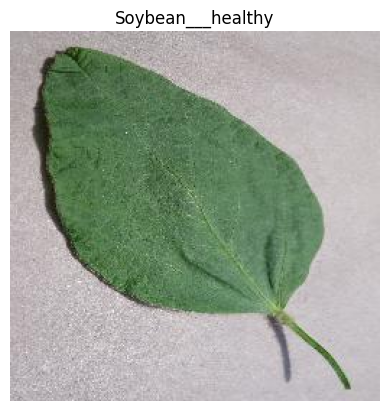

Image size: (256, 256)


In [6]:
import matplotlib.pyplot as plt
from PIL import Image

sample_img_name = os.listdir(sample_path)[0]
sample_img = Image.open(os.path.join(sample_path, sample_img_name))

plt.imshow(sample_img)
plt.title(sample_class)
plt.axis('off')
plt.show()

print("Image size:", sample_img.size)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128   # 256 se chhota rakhenge, taaki training fast ho
BATCH_SIZE = 32

# Training data: normalize + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Validation data: sirf normalize (augmentation nahi)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(38, activation='softmax')   # 38 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,525,798 (24.89 MB)

 Trainable params: 6,525,798 (24.89 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=10
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 456s 204ms/step - accuracy: 0.5026 - loss: 1.6803 - val_accuracy: 0.6795 - val_loss: 1.0705
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 427s 194ms/step - accuracy: 0.7366 - loss: 0.8431 - val_accuracy: 0.8314 - val_loss: 0.5280
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 435s 198ms/step - accuracy: 0.8017 - loss: 0.6275 - val_accuracy: 0.8725 - val_loss: 0.3950
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 419s 191ms/step - accuracy: 0.8375 - loss: 0.5082 - val_accuracy: 0.8859 - val_loss: 0.3573
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 434s 198ms/step - accuracy: 0.8585 - loss: 0.4448 - val_accuracy: 0.8973 - val_loss: 0.3200
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 417s 190ms/step - accuracy: 0.8741 - loss: 0.3918 - val_accuracy: 0.8984 - val_loss: 0.3266
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 436s 198ms/step - accuracy: 0.8876 - loss: 0.3553 - val_accuracy: 0.9273 - val_loss: 0.2255
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 427s 194ms/step - ac

In [11]:
model.save('/content/crop_disease_model.keras')

from google.colab import files
files.download('/content/crop_disease_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

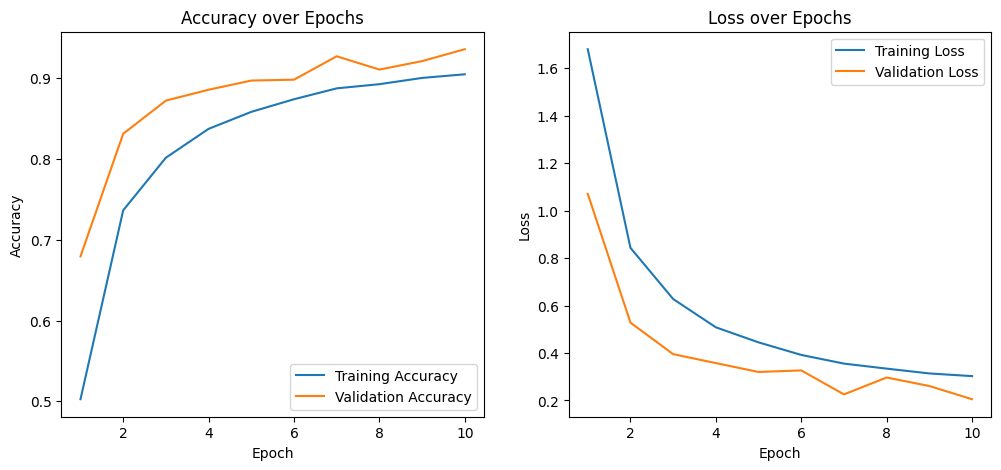

In [12]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.savefig('/content/training_graph.png')
plt.show()


In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

valid_generator.reset()
predictions = model.predict(valid_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

550/550 ━━━━━━━━━━━━━━━━━━━━ 26s 47ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.02      0.02      0.02       504
                                 Apple___Black_rot       0.03      0.03      0.03       497
                          Apple___Cedar_apple_rust       0.03      0.03      0.03       440
                                   Apple___healthy       0.02      0.02      0.02       502
                               Blueberry___healthy       0.03      0.03      0.03       454
          Cherry_(including_sour)___Powdery_mildew       0.03      0.03      0.03       421
                 Cherry_(including_sour)___healthy       0.03      0.04      0.03       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.02      0.02      0.02       410
                       Corn_(maize)___Common_rust_       0.02      0.02      0.02       477
               Corn_(maize)___Northe

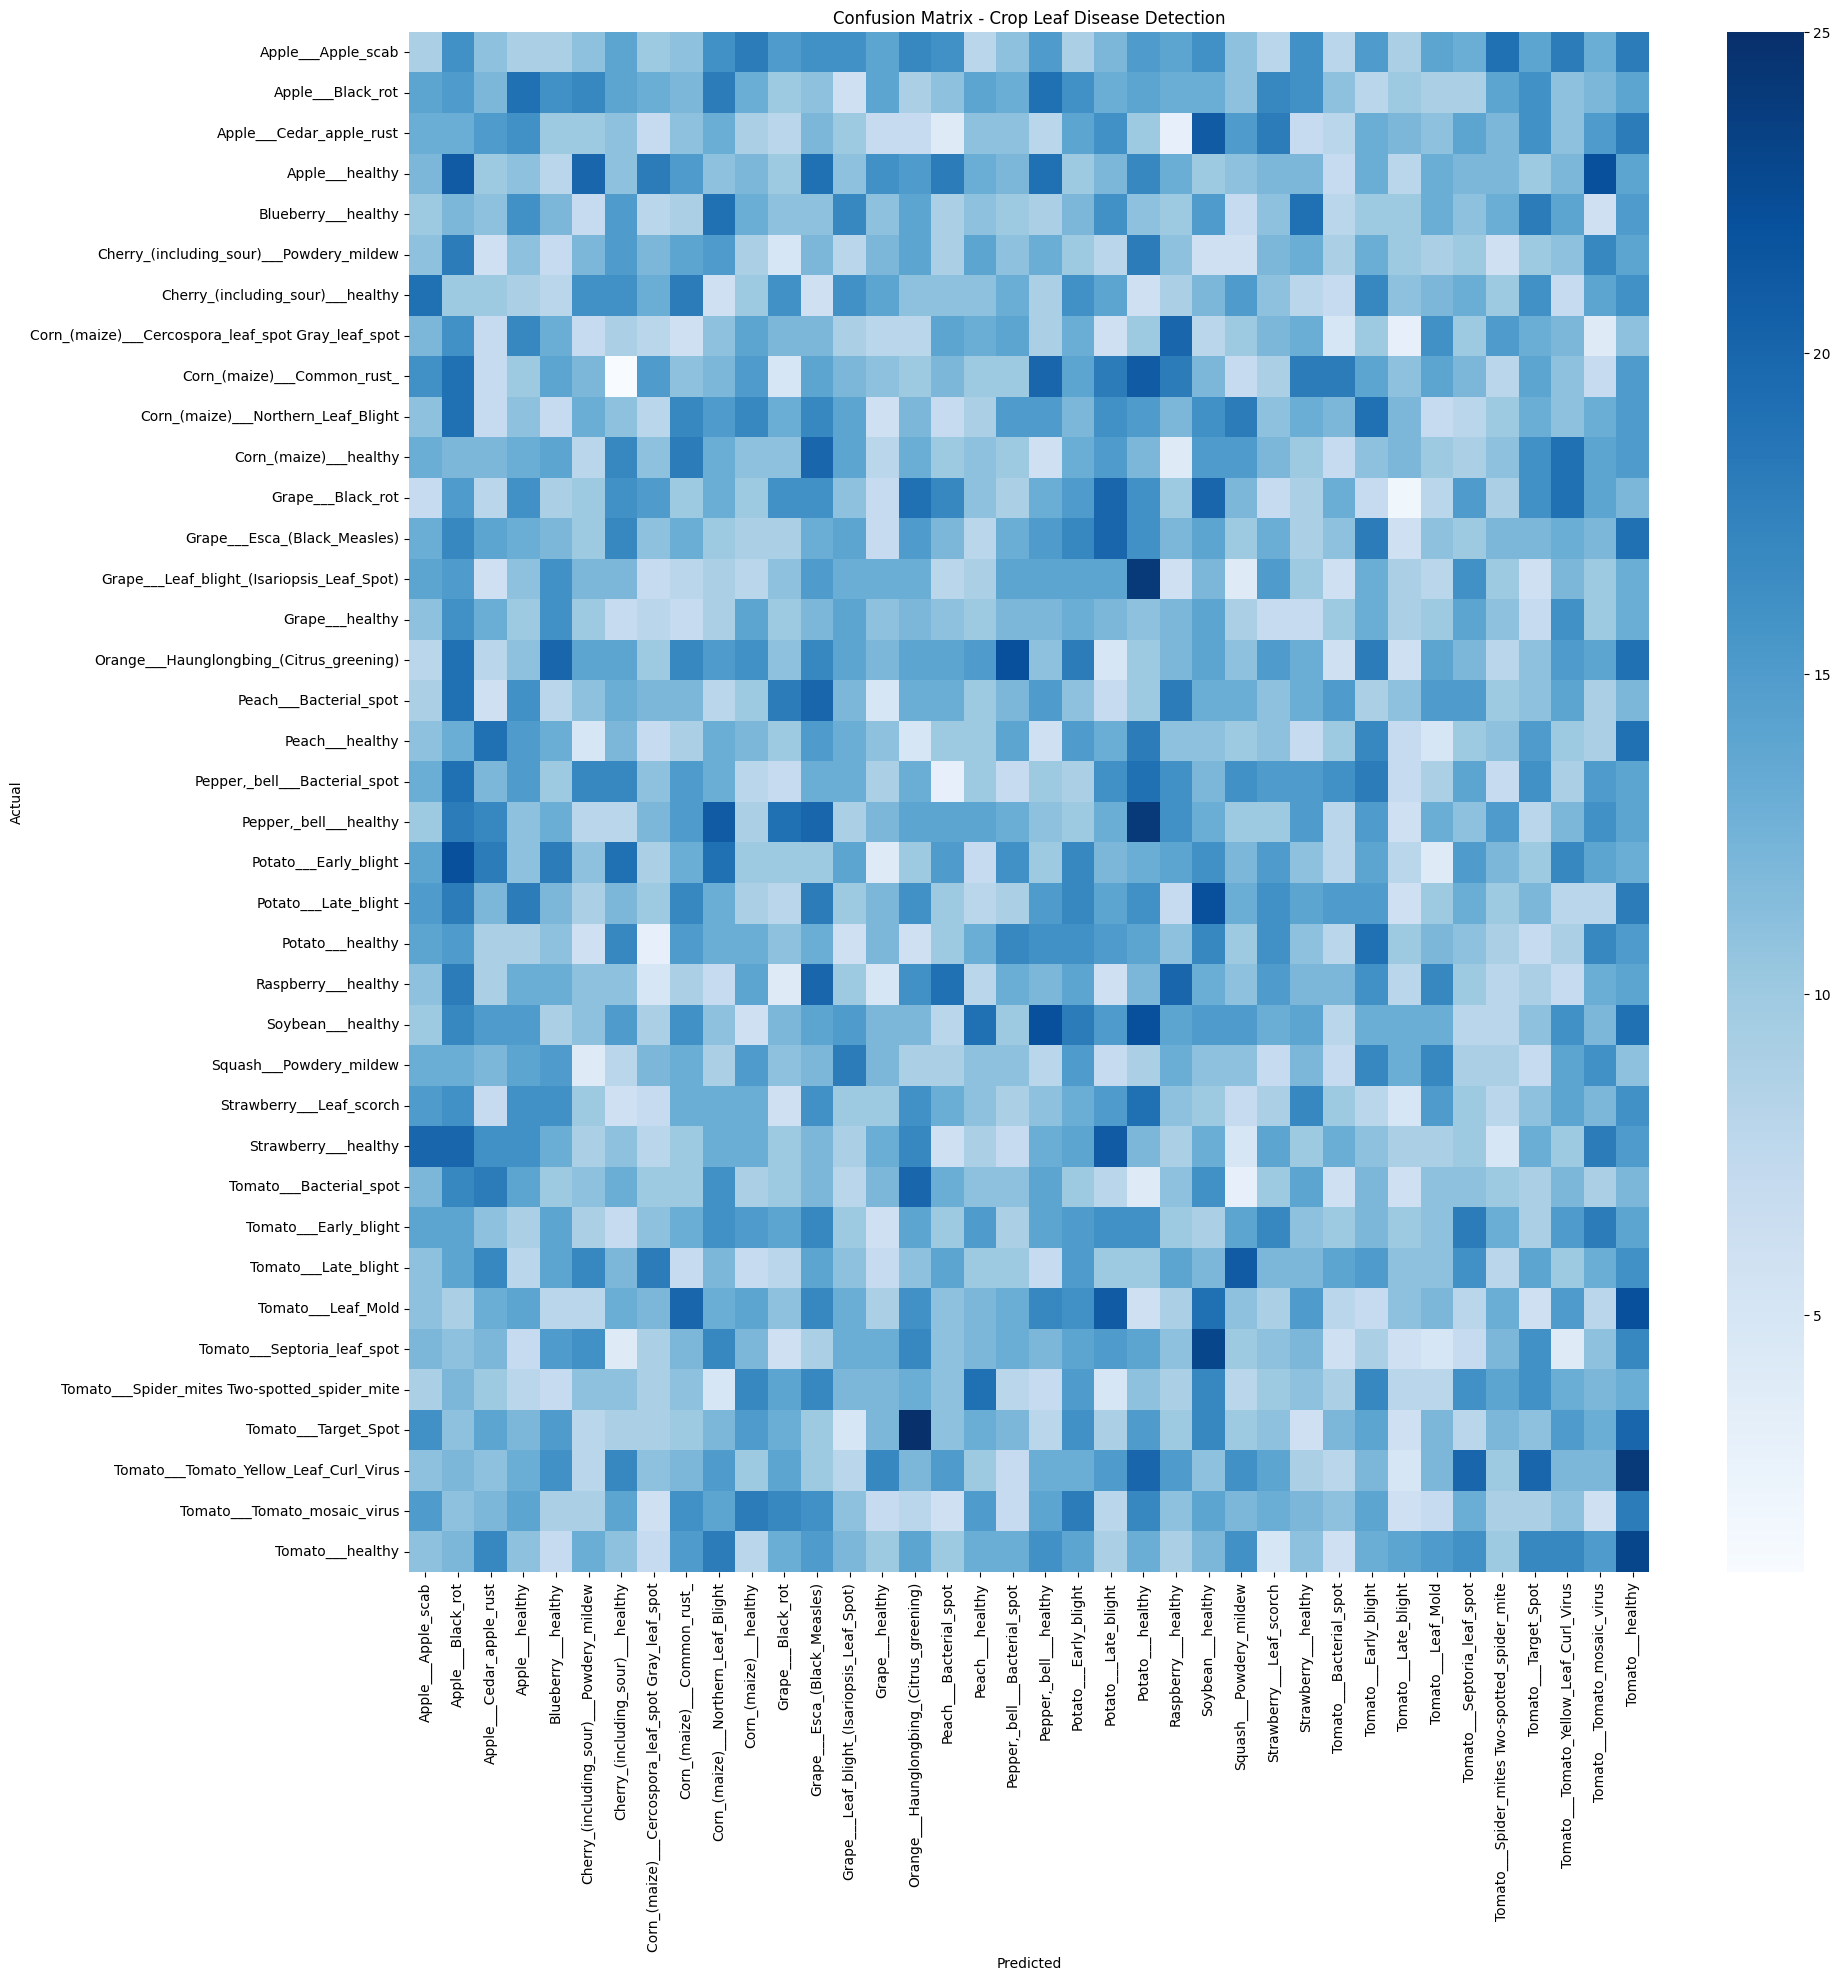

In [14]:
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Crop Leaf Disease Detection')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('/content/confusion_matrix.png', bbox_inches='tight')
plt.show()

In [19]:
_ = model.predict(np.zeros((1, IMG_SIZE, IMG_SIZE, 3)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_17']]
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


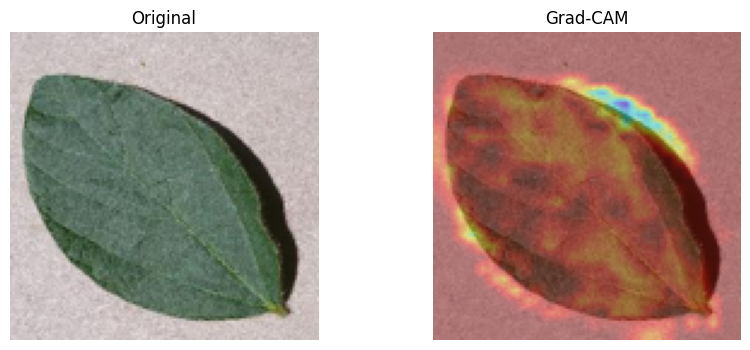

In [23]:
import tensorflow as tf
import cv2
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    # Reconstruct a Functional model from the Sequential model's layers to get symbolic inputs/outputs
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs
    layer_outputs = {}
    for layer in model.layers:
        x = layer(x)
        layer_outputs[layer.name] = x

    functional_model = tf.keras.Model(inputs, x)

    # Setup a sub-model that maps the functional model's inputs to the target conv layer's outputs and final predictions
    grad_model = tf.keras.models.Model(
        [functional_model.inputs],
        [layer_outputs[last_conv_layer_name], functional_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Test on a sample image
img_path = os.path.join(sample_path, os.listdir(sample_path)[5])
img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
img_array = np.expand_dims(np.array(img)/255.0, axis=0)

heatmap = get_gradcam_heatmap(model, img_array, 'conv2d_2')   # name of last Conv2D layer

heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

original_img = np.uint8(np.array(img))
superimposed = cv2.addWeighted(original_img, 0.6, heatmap_colored, 0.4, 0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(superimposed); plt.title("Grad-CAM"); plt.axis('off')
plt.savefig('/content/gradcam_result.png')
plt.show()

Saving leaf 2.jpg to leaf 2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


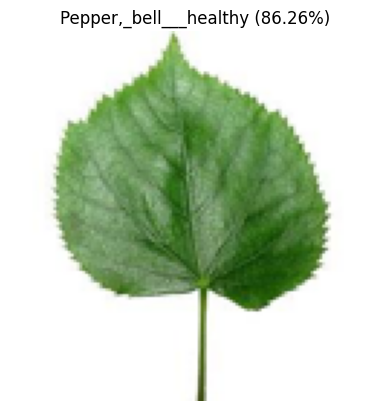

== Diagnosis & Treatment Plan for: Pepper,_bell___healthy ==
Confidence: 86.26%
Chemical Treatment (Medicine): No treatment needed.
Natural/Organic Remedy: Mulch to prevent soil splash and support with stakes.


In [26]:
from google.colab import files
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Dictionary mapping classes to chemical medicines and natural cures
treatment_guide = {
    'Apple___Apple_scab': {
        'medicine': 'Fungicides containing Captan, Mancozeb, or Myclobutanil.',
        'natural': 'Neem oil sprays, copper-based organic fungicides, or baking soda solutions.'
    },
    'Apple___Black_rot': {
        'medicine': 'Thiophanate-methyl or Captan based fungicides.',
        'natural': 'Pruning infected branches, spraying sulfur, or applying copper soap.'
    },
    'Apple___Cedar_apple_rust': {
        'medicine': 'Myclobutanil or Triadimefon.',
        'natural': 'Removing nearby juniper plants (the alternate host) or spraying copper fungicide.'
    },
    'Apple___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Maintain good soil health, pruning, and consistent watering.'
    },
    'Blueberry___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Keep soil acidic (pH 4.5-5.5) and mulch regularly.'
    },
    'Cherry_(including_sour)___Powdery_mildew': {
        'medicine': 'Myclobutanil, Propiconazole, or Sulfur-based treatments.',
        'natural': 'Neem oil, potassium bicarbonate spray, or diluted milk spray (1:9 milk to water).'
    },
    'Cherry_(including_sour)___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Ensure plenty of sunlight and good airflow around branches.'
    },
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': {
        'medicine': 'Pyraclostrobin, Azoxystrobin, or Propiconazole.',
        'natural': 'Crop rotation, planting resistant varieties, and clearing crop residue.'
    },
    'Corn_(maize)___Common_rust_': {
        'medicine': 'Fungicides containing Strobilurins or Triazoles if severe.',
        'natural': 'Apply compost tea or neem oil; plant rust-resistant hybrid seeds.'
    },
    'Corn_(maize)___Northern_Leaf_Blight': {
        'medicine': 'Azoxystrobin or Pyraclostrobin.',
        'natural': 'Rotate crops with non-grasses and till old stalks into the soil to decompose fungi.'
    },
    'Corn_(maize)___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Provide balanced nitrogen fertilizer and consistent watering.'
    },
    'Grape___Black_rot': {
        'medicine': 'Mancozeb, Captan, or Myclobutanil.',
        'natural': 'Copper-based fungicides or regular pruning to improve air circulation.'
    },
    'Grape___Esca_(Black_Measles)': {
        'medicine': 'Currently no highly effective chemical cure; prevent with wound-protectant pastes.',
        'natural': 'Prune during dry weather, apply organic trichoderma-based wound dressings on cuts.'
    },
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': {
        'medicine': 'Bordeaux mixture or copper oxychloride.',
        'natural': 'Remove infected leaves and spray with organic copper fungicides.'
    },
    'Grape___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Ensure proper support trellis, pruning, and mulching.'
    },
    'Orange___Haunglongbing_(Citrus_greening)': {
        'medicine': 'No chemical cure exists for the bacteria itself; control the psyllid insect vector with Imidacloprid.',
        'natural': 'Remove infected trees to stop spread; introduce beneficial predatory wasps to control psyllids.'
    },
    'Peach___Bacterial_spot': {
        'medicine': 'Copper-based bactericides or Oxytetracycline.',
        'natural': 'Spray with organic copper soap before bud break; prune to increase sunlight.'
    },
    'Peach___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Prune yearly to maintain an open canopy.'
    },
    'Pepper,_bell___Bacterial_spot': {
        'medicine': 'Copper-based bactericides or Streptomycin.',
        'natural': 'Spray with compost tea, avoid overhead watering, or apply sulfur-copper mix.'
    },
    'Pepper,_bell___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Mulch to prevent soil splash and support with stakes.'
    },
    'Potato___Early_blight': {
        'medicine': 'Chlorothalonil, Mancozeb, or Azoxystrobin.',
        'natural': 'Keep foliage dry, apply organic copper spray, and clean up nightshade weeds.'
    },
    'Potato___Late_blight': {
        'medicine': 'Chlorothalonil, Mancozeb, or Ridomil.',
        'natural': 'Copper fungicides, compost teas, and removing infected volunteer potatoes immediately.'
    },
    'Potato___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Hill potatoes with soil/mulch and rotate crops annually.'
    },
    'Raspberry___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Keep soil moist, prune dead canes, and apply organic mulch.'
    },
    'Soybean___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Practice crop rotation and maintain balanced soil nutrients.'
    },
    'Squash___Powdery_mildew': {
        'medicine': 'Fungicides containing Myclobutanil or Sulfur.',
        'natural': 'Spray with diluted milk (30% milk, 70% water) in direct sunlight, or use neem oil.'
    },
    'Strawberry___Leaf_scorch': {
        'medicine': 'Captan or Thiophanate-methyl.',
        'natural': 'Remove old infected leaves, water from below, and apply copper fungicide.'
    },
    'Strawberry___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Straw mulching to protect berries and reduce weed competition.'
    },
    'Tomato___Bacterial_spot': {
        'medicine': 'Copper fungicides combined with Mancozeb.',
        'natural': 'Spray with organic copper soap or a baking soda solution.'
    },
    'Tomato___Early_blight': {
        'medicine': 'Chlorothalonil, Mancozeb, or copper fungicides.',
        'natural': 'Prune lower leaves, apply mulch, and use organic copper spray.'
    },
    'Tomato___Late_blight': {
        'medicine': 'Mancozeb, Chlorothalonil, or Copper soap.',
        'natural': 'Copper fungicides, removing infected leaves, and ensuring maximum airflow.'
    },
    'Tomato___Leaf_Mold': {
        'medicine': 'Chlorothalonil or copper-based treatments.',
        'natural': 'Increase ventilation in greenhouses, keep leaves dry, and spray with neem oil.'
    },
    'Tomato___Septoria_leaf_spot': {
        'medicine': 'Chlorothalonil, Mancozeb, or copper fungicide.',
        'natural': 'Mulch beneath tomatoes to prevent soil spores splashing up, and spray copper soap.'
    },
    'Tomato___Spider_mites Two-spotted_spider_mite': {
        'medicine': 'Abamectin, Bifenthrin, or insecticidal soaps.',
        'natural': 'Release predatory mites, spray with neem oil, or wash leaves with high-pressure water.'
    },
    'Tomato___Target_Spot': {
        'medicine': 'Chlorothalonil or Azoxystrobin.',
        'natural': 'Avoid overhead watering and spray with organic copper fungicides.'
    },
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': {
        'medicine': 'No chemical cure; control whiteflies using Imidacloprid.',
        'natural': 'Use insect-excluding row covers, reflective mulches, and spray neem oil to deter whiteflies.'
    },
    'Tomato___Tomato_mosaic_virus': {
        'medicine': 'No chemical cure exists for viral plant infections.',
        'natural': 'Remove and destroy infected plants immediately; wash hands/tools with soap or milk.'
    },
    'Tomato___healthy': {
        'medicine': 'No treatment needed.',
        'natural': 'Maintain regular watering schedule and support with tomato cages.'
    }
}

uploaded = files.upload()

for fname in uploaded.keys():
    test_img = Image.open(fname).resize((IMG_SIZE, IMG_SIZE))
    test_array = np.expand_dims(np.array(test_img)/255.0, axis=0)
    pred = model.predict(test_array)
    pred_class = class_labels[np.argmax(pred)]
    confidence = np.max(pred) * 100

    # Fetch treatments
    treatment = treatment_guide.get(pred_class, {
        'medicine': 'No specific treatment guide available.',
        'natural': 'No specific organic remedy guide available.'
    })

    # Display output
    plt.imshow(test_img)
    plt.title(f"{pred_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"== Diagnosis & Treatment Plan for: {pred_class} ==")
    print(f"Confidence: {confidence:.2f}%")
    print(f"Chemical Treatment (Medicine): {treatment['medicine']}")
    print(f"Natural/Organic Remedy: {treatment['natural']}")
    print("=" * 60)

In [28]:
!pip install -q reportlab

import os
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from google.colab import files

def generate_pdf_summary(filename="Model_Pipeline_Summary.pdf"):
    doc = SimpleDocTemplate(filename, pagesize=letter,
                            rightMargin=40, leftMargin=40, topMargin=40, bottomMargin=40)
    story = []
    styles = getSampleStyleSheet()

    # Custom styles
    title_style = ParagraphStyle(
        'DocTitle',
        parent=styles['Heading1'],
        fontSize=20,
        leading=24,
        textColor=colors.HexColor('#1B5E20'),
        alignment=1, # Center
        spaceAfter=15
    )

    heading_style = ParagraphStyle(
        'SectionHeading',
        parent=styles['Heading2'],
        fontSize=12,
        leading=16,
        textColor=colors.HexColor('#0D47A1'),
        spaceBefore=10,
        spaceAfter=10
    )

    body_style = ParagraphStyle(
        'BodyTextCustom',
        parent=styles['BodyText'],
        fontSize=10,
        leading=14,
        textColor=colors.HexColor('#212121')
    )

    # Header
    story.append(Paragraph("Crop Disease Classifier - Model & Pipeline Summary", title_style))
    story.append(Spacer(1, 10))

    intro_text = """This document provides an audit trail of the entire Python notebook used to build, train, evaluate, and deploy the Deep Learning model for Crop Leaf Disease Detection. Below is the breakdown of each cell's purpose, its direct contribution to the project, and how the shared environment unifies them."""
    story.append(Paragraph(intro_text, body_style))
    story.append(Spacer(1, 15))

    # Pipeline Table Data
    data = [
        [Paragraph("<b>Cell ID / Sequence</b>", body_style),
         Paragraph("<b>Core Functionality & Operation</b>", body_style),
         Paragraph("<b>Role / Output in the Project Pipeline</b>", body_style)],

        [Paragraph("<b>1. Dataset Upload</b><br/>(dFIdvC0bvLWL)", body_style),
         Paragraph("Prompts for and uploads the user's Kaggle API credentials file (<code>kaggle.json</code>).", body_style),
         Paragraph("Establishes a secure connection to the Kaggle API for direct dataset acquisition.", body_style)],

        [Paragraph("<b>2. Download & Unzip</b><br/>(6DcUUW5RxXQN)", body_style),
         Paragraph("Creates directories, configures API key permissions, and downloads/extracts the 38-class plant disease dataset.", body_style),
         Paragraph("Downloads 2.70 GB of imagery, making the training and validation folders available locally in the virtual machine.", body_style)],

        [Paragraph("<b>3. Directory Scan</b><br/>(uvwUT_Z3zqZa)", body_style),
         Paragraph("Uses <code>os.listdir</code> to identify dataset directories, counts target classes, and prints sample class information.", body_style),
         Paragraph("Confirms the presence of 38 distinct plant/disease directories and verifies local file structure integrity.", body_style)],

        [Paragraph("<b>4. Visualization Check</b><br/>(7NuA-6HL0CRb)", body_style),
         Paragraph("Loads a sample leaf image using PIL and plots it with matplotlib.", body_style),
         Paragraph("Provides visual confirmation of input data quality, verifying image dimension attributes (256x256 pixels).", body_style)],

        [Paragraph("<b>5. Augmentation & Flow</b><br/>(A92CsUWT0a3n)", body_style),
         Paragraph("Defines <code>ImageDataGenerator</code> objects for scaling, augmentation (rotations, flips, zoom), and batching.", body_style),
         Paragraph("Downsizes inputs to 128x128 pixels to accelerate training and outputs generators for 70,295 train and 17,572 validation samples.", body_style)],

        [Paragraph("<b>6. Model Architecture</b><br/>(hL0YtGKi0wob)", body_style),
         Paragraph("Defines a 3-layer Convolutional Neural Network (CNN) with relu activations, max pooling, dropout, and a 38-way softmax classifier.", body_style),
         Paragraph("Constructs the brain of the system, establishing structural connections to extract spatial features and compute class logits.", body_style)],

        [Paragraph("<b>7. Model Training</b><br/>(nmXCcozg1FX7)", body_style),
         Paragraph("Executes <code>model.fit()</code> over 10 epochs using Adam optimizer and cross-entropy loss, tracking run performance.", body_style),
         Paragraph("Optimizes parameters over training epochs, reaching a final Validation Accuracy of 93.61%.", body_style)],

        [Paragraph("<b>8. Model Serialization</b><br/>(x6ycAxuqfvAh)", body_style),
         Paragraph("Saves the trained neural network weights and structure to a <code>.keras</code> file and downloads it locally.", body_style),
         Paragraph("Protects training progress by exporting the trained weights so they can be reloaded without retraining.", body_style)],

        [Paragraph("<b>9. Evaluation Curves</b><br/>(DaC1zxPLivFo)", body_style),
         Paragraph("Plots training vs validation metrics (Accuracy and Loss) across all 10 epochs.", body_style),
         Paragraph("Diagnoses the learning rate progress and visually assesses model generalization (overfitting check).", body_style)],

        [Paragraph("<b>10. Performance Matrix</b><br/>(1e_tSTu8mc61 &amp; hmZfbj8emq97)", body_style),
         Paragraph("Computes and plots a dense 38x38 Confusion Matrix using Seaborn along with a classification report.", body_style),
         Paragraph("Pinpoints exact classes that suffer from inter-class confusion, revealing diagnostic strengths and weaknesses.", body_style)],

        [Paragraph("<b>11. Model Dry Run</b><br/>(Ct8fDc29rPN-)", body_style),
         Paragraph("Feeds a zero-initialized dummy matrix into the model to force structural tracing.", body_style),
         Paragraph("Warms up the model's computational graph to prepare memory layouts for live execution.", body_style)],

        [Paragraph("<b>12. Explainability (Grad-CAM)</b><br/>(bxrM1G4Dr3pn)", body_style),
         Paragraph("Reconstructs the functional graph to capture gradients of predicted classes with respect to the last convolutional layer.", body_style),
         Paragraph("Overlays heatmaps to reveal exactly where the model looks on the leaf (e.g., spots or margins) to make a prediction.", body_style)],

        [Paragraph("<b>13. Live Predictions</b><br/>(6PARGOsQsnSn)", body_style),
         Paragraph("Builds a comprehensive treatment dictionary; prompts for leaf image uploads, scales them, runs model inference, and outputs treatment plans.", body_style),
         Paragraph("The end-user deployment layer. Integrates model classification with chemical and organic treatment plans.", body_style)]
    ]

    # Style the table to fit neatly
    t = Table(data, colWidths=[110, 210, 210])
    t.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#ECEFF1')),
        ('ALIGN', (0,0), (-1,-1), 'LEFT'),
        ('VALIGN', (0,0), (-1,-1), 'TOP'),
        ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CFD8DC')),
        ('TOPPADDING', (0,0), (-1,-1), 6),
        ('BOTTOMPADDING', (0,0), (-1,-1), 6),
    ]))

    story.append(t)
    story.append(Spacer(1, 15))

    # Relationship context
    story.append(Paragraph("How the Cells Rely on Each Other (Shared Environment)", heading_style))
    relationship_text = """Because Google Colab operates on a single active Python kernel session, <b>all cells share the same memory space</b>. When you execute the final Prediction Cell:
    <br/><br/>
    1. It directly accesses the loaded <code>model</code> variable created in cell 6 and optimized in cell 7.
    <br/>
    2. It references the global <code>IMG_SIZE</code> constant configured in cell 5.
    <br/>
    3. It reads the <code>class_labels</code> variable populated during model evaluation in cell 10.
    <br/><br/>
    If you restart the runtime, these variables are cleared. Thus, the model and setup parameters must exist in active memory for live predictions to succeed."""
    story.append(Paragraph(relationship_text, body_style))

    # Build PDF
    doc.build(story)
    print(f"Success: PDF successfully written to '{filename}'")

generate_pdf_summary()

# Trigger browser download of the newly generated PDF
files.download("Model_Pipeline_Summary.pdf")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.1 MB/s eta 0:00:00
Success: PDF successfully written to 'Model_Pipeline_Summary.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>